In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
# Import Libraries

In [2]:
df=pd.read_csv("AQI.csv")
# Load Dataset

# Regression (Target = AQI value)

Business Problem:
Predict the exact Air Quality Index (AQI) for a given location and time to help authorities and organizations take proactive measures.

In [3]:
df.head()
# Display top 5 rows

,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,Ahmedabad,2015-01-01,NaN,NaN,0.92,18.22,17.15,NaN,0.92,27.64,133.36,0.00,0.02,0.00,NaN,NaN
1,Ahmedabad,2015-01-02,NaN,NaN,0.97,15.69,16.46,NaN,0.97,24.55,34.06,3.68,5.50,3.77,NaN,NaN
2,Ahmedabad,2015-01-03,NaN,NaN,17.40,19.30,29.70,NaN,17.40,29.07,30.70,6.80,16.40,2.25,NaN,NaN
3,Ahmedabad,2015-01-04,NaN,NaN,1.70,18.48,17.97,NaN,1.70,18.59,36.08,4.43,10.14,1.00,NaN,NaN
4,Ahmedabad,2015-01-05,NaN,NaN,22.10,21.42,37.76,NaN,22.10,39.33,39.31,7.01,18.89,2.78,NaN,NaN


In [4]:
df.shape
# Shape of the dataset

(29531, 16)

In [5]:
df.info()
# detail information of our dataset

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29531 entries, 0 to 29530
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   City        29531 non-null  object 
 1   Date        29531 non-null  object 
 2   PM2.5       24933 non-null  float64
 3   PM10        18391 non-null  float64
 4   NO          25949 non-null  float64
 5   NO2         25946 non-null  float64
 6   NOx         25346 non-null  float64
 7   NH3         19203 non-null  float64
 8   CO          27472 non-null  float64
 9   SO2         25677 non-null  float64
 10  O3          25509 non-null  float64
 11  Benzene     23908 non-null  float64
 12  Toluene     21490 non-null  float64
 13  Xylene      11422 non-null  float64
 14  AQI         24850 non-null  float64
 15  AQI_Bucket  24850 non-null  object 
dtypes: float64(13), object(3)
memory usage: 3.6+ MB


In [6]:
df.isnull().sum()
# checking missing values

City              0
Date              0
PM2.5          4598
PM10          11140
NO             3582
NO2            3585
NOx            4185
NH3           10328
CO             2059
SO2            3854
O3             4022
Benzene        5623
Toluene        8041
Xylene        18109
AQI            4681
AQI_Bucket     4681
dtype: int64

In [7]:
df = df.drop(columns=["NH3","PM10","Toluene","Xylene","AQI_Bucket","Date"])
# drop those columns to remove irrelevant that don’t help (or can hurt) the model’s performance.

In [8]:
df["PM2.5"]=df["PM2.5"].fillna(df["PM2.5"].median())
df["NO"]=df["NO"].fillna(df["NO"].median())
df["NO2"]=df["NO2"].fillna(df["NO2"].median())
df["NOx"]=df["NOx"].fillna(df["NOx"].median())
df["CO"]=df["CO"].fillna(df["CO"].median())
df["SO2"]=df["SO2"].fillna(df["SO2"].median())
df["O3"]=df["O3"].fillna(df["O3"].median())
df["Benzene"]=df["Benzene"].fillna(df["Benzene"].median())
df["AQI"]=df["AQI"].fillna(df["AQI"].median())
# filling the missing values with median values instead of droppping the rows.

In [9]:
df.isnull().sum()

City       0
PM2.5      0
NO         0
NO2        0
NOx        0
CO         0
SO2        0
O3         0
Benzene    0
AQI        0
dtype: int64

In [10]:
df.duplicated().sum()
# checking duplicate values

np.int64(2334)

In [11]:
df = df.drop_duplicates()
# drop the duplicate rows

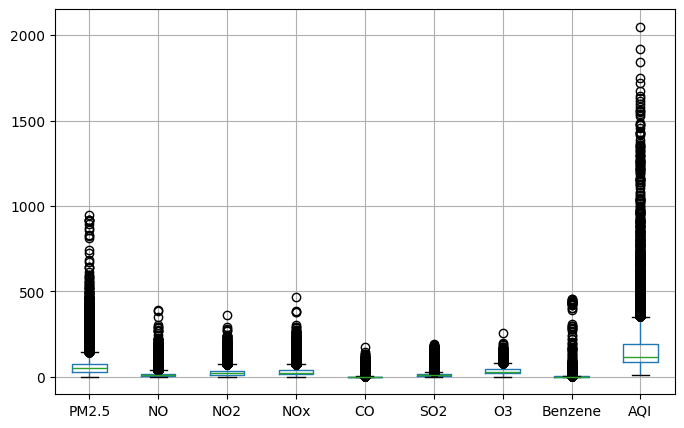

In [12]:
df.boxplot(figsize=(8,5))
plt.show()
# detecting outliers

In [13]:
cols = ["PM2.5","NO","NO2","NOx","CO","SO2","O3","Benzene"]
for col in cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df[col] = df[col].clip(lower, upper)
# clipping my outliers using IQR,lower bound and upper bound technique

In [14]:
y = df["AQI"] 
# target varaible

In [15]:
X=df.drop(["AQI"],axis=1)
# input features

In [20]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2)
# splitting the dataset into training and testing

In [21]:
print(X_train.shape)
print(X_test.shape)

(21757, 9)
(5440, 9)


### KNN Regression

In [53]:
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsRegressor
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder,StandardScaler

transformer = ColumnTransformer(transformers=[("CATEGORICAL",OrdinalEncoder(),[0]),
                                  ("NUMERICAL",StandardScaler(),[1,2,3,4,5,6,7,8])])

In [54]:
pipe_knn = Pipeline(steps=[
    ('preprocessor', transformer),
    ('model', KNeighborsRegressor())
])

In [35]:
#perfoming hyperparameter tuning
from sklearn.model_selection import GridSearchCV
knnc = KNeighborsRegressor()
param_grid = {
    'model__n_neighbors':[3,5,7,9],
    'model__weights':["uniform",'distance'],
    'model__p':[1,2]}
grid_knn = GridSearchCV(estimator=pipe_knn,param_grid=param_grid,cv=5,scoring='r2',verbose=1)
grid_knn.fit(X_train,y_train)

Fitting 5 folds for each of 16 candidates, totalling 80 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...Regressor())])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__n_neighbors': [3, 5, ...], 'model__p': [1, 2], 'model__weights': ['uniform', 'distance']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed

In [37]:
# getting the best parameters and cv accuracy value
print("Best parameters :",grid_knn.best_params_)
print("Best CV accuracy:",grid_knn.best_score_)

Best parameters : {'model__n_neighbors': 9, 'model__p': 1, 'model__weights': 'distance'}
Best CV accuracy: 0.8466895743458837


In [38]:
y_pred=grid_knn.predict(X_test)
y_train_pred = grid_knn.predict(X_train)
# prediction the output value of training and testing

In [40]:
# R2_score for knn algorithm
from sklearn.metrics import r2_score
score = r2_score(y_pred,y_test)
train = r2_score(y_train_pred,y_train)
print("K NEAREST NEIGHBOR REGRESSION")
print("R2 SCORE OF TRAINING :",train)
print("R2 SCORE OF TESTING :",score)

K NEAREST NEIGHBOR REGRESSION
R2 SCORE OF TRAINING : 0.9995037810933802
R2 SCORE OF TESTING : 0.818775386766388


In [64]:
# KNN model showed very high training R² (~0.99) but lower test R² (~0.81), indicating overfitting.

### Decision Tree Regressor

In [55]:
from sklearn.tree import DecisionTreeRegressor

In [56]:
pipe_dt = Pipeline(steps=[
    ('preprocessor', transformer),
    ('model', DecisionTreeRegressor(random_state=42))
])

In [59]:
from sklearn.model_selection import RandomizedSearchCV
param_grid = {
    "model__max_depth": [3, 5, 10],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4]
}
tree_cv = RandomizedSearchCV(pipe_dt, param_grid, cv=5, n_jobs=-1)
tree_cv.fit(X_train, y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__max_depth': [3, 5, ...], 'model__min_samples_leaf': [1, 2, ...], 'model__min_samples_split': [2, 5, ...]}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.

In [61]:
print("Best parameters :",tree_cv.best_params_)
print("Best CV accuracy:",tree_cv.best_score_)

Best parameters : {'model__min_samples_split': 5, 'model__min_samples_leaf': 1, 'model__max_depth': 5}
Best CV accuracy: 0.8010209773436806


In [62]:
y_pred=tree_cv.predict(X_test)
y_train_pred = tree_cv.predict(X_train)

In [63]:
score = r2_score(y_pred,y_test)
train = r2_score(y_train_pred,y_train)
print("DECISION TREE REGRESSION")
print("R2 SCORE OF TRAINING :",train)
print("R2 SCORE OF TESTING :",score)

DECISION TREE REGRESSION
R2 SCORE OF TRAINING : 0.7961940396669003
R2 SCORE OF TESTING : 0.7508692230842482


In [ ]:
# The model shows balanced performance (Train R² ≈ 0.80, Test R² ≈ 0.75), indicating good generalization with minimal overfitting.
# Slight drop from training to testing suggests minor variance, but overall the model is reliable and not over-complex.

In [49]:
import warnings
warnings.filterwarnings('ignore')

# Classification (Target = AQI Bucket)

Business Problem:
Classify air quality into categories (Good, Moderate, Poor, etc.) to enable quick decision-making and public communication.

In [168]:
df=pd.read_csv("AQI.csv")

In [169]:
df.isnull().sum()

City              0
Date              0
PM2.5          4598
PM10          11140
NO             3582
NO2            3585
NOx            4185
NH3           10328
CO             2059
SO2            3854
O3             4022
Benzene        5623
Toluene        8041
Xylene        18109
AQI            4681
AQI_Bucket     4681
dtype: int64

In [170]:
df = df.drop(columns=["PM10","NH3","Date","Toluene","Benzene","Xylene","AQI"])

In [171]:
df["PM2.5"]=df["PM2.5"].fillna(df["PM2.5"].median())
df["NO"]=df["NO"].fillna(df["NO"].median())
df["NO2"]=df["NO2"].fillna(df["NO2"].median())
df["NOx"]=df["NOx"].fillna(df["NOx"].median())
df["CO"]=df["CO"].fillna(df["CO"].median())
df["SO2"]=df["SO2"].fillna(df["SO2"].median())
df["O3"]=df["O3"].fillna(df["O3"].median())

In [172]:
df["AQI_Bucket"] = df["AQI_Bucket"].astype(str)
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df["AQI_Bucket"] = le.fit_transform(df["AQI_Bucket"])

In [173]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29531 entries, 0 to 29530
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   City        29531 non-null  object 
 1   PM2.5       29531 non-null  float64
 2   NO          29531 non-null  float64
 3   NO2         29531 non-null  float64
 4   NOx         29531 non-null  float64
 5   CO          29531 non-null  float64
 6   SO2         29531 non-null  float64
 7   O3          29531 non-null  float64
 8   AQI_Bucket  29531 non-null  int64  
dtypes: float64(7), int64(1), object(1)
memory usage: 2.0+ MB


In [174]:
df.isnull().sum()

City          0
PM2.5         0
NO            0
NO2           0
NOx           0
CO            0
SO2           0
O3            0
AQI_Bucket    0
dtype: int64

In [175]:
y = df["AQI_Bucket"]
# target variable

In [176]:
X = df.drop(columns=["AQI_Bucket"])
# input features

In [177]:
print(y.shape)
print(X.shape)

(29531,)
(29531, 8)


In [178]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2)
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(23624, 8)
(5907, 8)
(23624,)
(5907,)


In [179]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29531 entries, 0 to 29530
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   City    29531 non-null  object 
 1   PM2.5   29531 non-null  float64
 2   NO      29531 non-null  float64
 3   NO2     29531 non-null  float64
 4   NOx     29531 non-null  float64
 5   CO      29531 non-null  float64
 6   SO2     29531 non-null  float64
 7   O3      29531 non-null  float64
dtypes: float64(7), object(1)
memory usage: 1.8+ MB


### KNN Classification

In [180]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier

preprocessor =ColumnTransformer(transformers=[("CATEGORICAL",OrdinalEncoder(),[0]),
    ("numerical",StandardScaler(),[1,2,3,4,5,6,7])])

In [181]:
pipe = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', KNeighborsClassifier())
])

In [182]:
knnc = KNeighborsClassifier()
param_grid = {
    'model__n_neighbors':[3,5,7,9],
    'model__weights':["uniform",'distance'],
    'model__p':[1,2]}
grid1 = RandomizedSearchCV(pipe,param_grid,cv=5,scoring='accuracy',verbose=1)
grid1.fit(X_train,y_train)

Fitting 5 folds for each of 10 candidates, totalling 50 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...lassifier())])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__n_neighbors': [3, 5, ...], 'model__p': [1, 2], 'model__weights': ['uniform', 'distance']}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`

In [183]:
print("Best parameters :",grid1.best_params_)
print("Best CV accuracy:",grid1.best_score_)

Best parameters : {'model__weights': 'distance', 'model__p': 1, 'model__n_neighbors': 7}
Best CV accuracy: 0.7531324184956699


In [184]:
y_pred_test = grid1.predict(X_test)
y_pred_train = grid1.predict(X_train)

In [185]:
from sklearn.metrics import accuracy_score
print("ACCURACY SCORE FOR KNN")
acc = accuracy_score(y_test,y_pred_test)
print("Accuracy Score of Testing:",acc)
acc1 = accuracy_score(y_train,y_pred_train)
print("Accuracy Score of Training:",acc1)

ACCURACY SCORE FOR KNN
Accuracy Score of Testing: 0.7514812933807348
Accuracy Score of Training: 0.9984337961395191


In [191]:
# The model shows severe overfitting (Training ≈ 0.998 vs Testing ≈ 0.756), meaning it memorizes training data but fails to generalize well.

In [192]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_test))

              precision    recall  f1-score   support

           0       0.38      0.42      0.40       281
           1       0.68      0.48      0.56      1724
           2       0.47      0.30      0.37       546
           3       0.47      0.85      0.61      1686
           4       0.66      0.72      0.69       268
           5       0.60      0.51      0.55       452
           6       0.15      0.05      0.08       950

    accuracy                           0.51      5907
   macro avg       0.49      0.48      0.46      5907
weighted avg       0.49      0.51      0.48      5907



# Naive Bayes Classification

In [193]:
from sklearn.naive_bayes import GaussianNB

In [194]:
pipe2 = Pipeline(steps=[
    ('preprocessing', preprocessor),
    ('model', GaussianNB())
])
pipe2.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessing', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('CATEGORICAL', ...), ('numerical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different 

In [195]:
y_pred_test = pipe2.predict(X_test)
y_pred_train = pipe2.predict(X_train)

In [196]:
print("ACCURACY SCORE FOR GAUSSIAN NAIVE BAYES")
acc = accuracy_score(y_test,y_pred_test)
print("Accuracy Score of Testing:",acc)
acc1 = accuracy_score(y_train,y_pred_train)
print("Accuracy Score of Training:",acc1)

ACCURACY SCORE FOR GAUSSIAN NAIVE BAYES
Accuracy Score of Testing: 0.5090570509564923
Accuracy Score of Training: 0.5115137148662378


In [197]:
# The model shows very low and similar train/test accuracy (~50%), indicating underfitting and poor ability to capture patterns in the AQI data.

In [198]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_test))

              precision    recall  f1-score   support

           0       0.38      0.42      0.40       281
           1       0.68      0.48      0.56      1724
           2       0.47      0.30      0.37       546
           3       0.47      0.85      0.61      1686
           4       0.66      0.72      0.69       268
           5       0.60      0.51      0.55       452
           6       0.15      0.05      0.08       950

    accuracy                           0.51      5907
   macro avg       0.49      0.48      0.46      5907
weighted avg       0.49      0.51      0.48      5907



# Decison Trees

In [199]:
from sklearn.tree import DecisionTreeClassifier

In [200]:
pipe3=Pipeline(steps=[
    ('preprocessing', preprocessor),
    ('model', DecisionTreeClassifier())
])

In [201]:
params={
    "model__criterion":("gini","entropy"),
    "model__splitter":("best","random"),
    "model__max_depth":(list(range(1,10))),
    "model__min_samples_leaf":list(range(1,8))
}
tree_clf = DecisionTreeClassifier()
tree_cv = RandomizedSearchCV(pipe3,params,scoring = "accuracy",n_jobs=-1,verbose = 1,cv=5)
tree_cv.fit(X_train,y_train)

Fitting 5 folds for each of 10 candidates, totalling 50 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...lassifier())])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__criterion': ('gini', ...), 'model__max_depth': [1, 2, ...], 'model__min_samples_leaf': [1, 2, ...], 'model__splitter': ('best', ...)}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can b

In [202]:
print("Best parameters :",tree_cv.best_params_)
print("Best CV accuracy:",tree_cv.best_score_)

Best parameters : {'model__splitter': 'best', 'model__min_samples_leaf': 2, 'model__max_depth': 9, 'model__criterion': 'entropy'}
Best CV accuracy: 0.7481799927422281


In [203]:
y_pred_test3 = tree_cv.predict(X_test)
y_pred_train3=tree_cv.predict(X_train)

In [204]:
from sklearn.metrics import accuracy_score
print("ACCURACY SCORE FOR DECISION TREE")
acc = accuracy_score(y_test,y_pred_test3)
print("Accuracy Score of Testing:",acc)
acc1 = accuracy_score(y_train,y_pred_train3)
print("Accuracy Score of Training:",acc1)

ACCURACY SCORE FOR DECISION TREE
Accuracy Score of Testing: 0.7452175385136279
Accuracy Score of Training: 0.7844988147646461


In [206]:
# The model shows good and balanced performance (train ≈ 0.78, test ≈ 0.74), indicating minimal overfitting and decent generalization

In [207]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_test))

              precision    recall  f1-score   support

           0       0.38      0.42      0.40       281
           1       0.68      0.48      0.56      1724
           2       0.47      0.30      0.37       546
           3       0.47      0.85      0.61      1686
           4       0.66      0.72      0.69       268
           5       0.60      0.51      0.55       452
           6       0.15      0.05      0.08       950

    accuracy                           0.51      5907
   macro avg       0.49      0.48      0.46      5907
weighted avg       0.49      0.51      0.48      5907

